In [1]:
# import necessary packages
import numpy as np
import pandas as pd
import re, importlib
from tqdm import tqdm
import os, sys, json
from itertools import product
from web_model import params, model  # Load parameters and model implementation.
from pathlib import Path
import time
import PBcombos as pbc
from collections import Counter
print(os.getcwd())
importlib.reload(model)
importlib.reload(pbc)
pd.options.display.float_format = "{:20,.4f}".format
print(pd.__version__)
print(np.__version__)

root_path = Path().parent

param_list = list(params.df_typing_formatting.T.to_dict().values())
model_params = {row["keys"]: row["values"] for row in param_list}
sm = model.SolveModel(model_params)
prod_change_dict = sm.prod_change_dict

/home/gustav/dev/pbtech
2.2.2
1.26.4


In [ ]:
def check(discrete_vals = [0,1], param_idx_restrict_vals=None, file_name_extension=''):
    """ Method for assessing outcome of policy combinatins"""
    good_for_all_pbs = []
    pb_improvement_cnts = {}
    pb_improvement_cnt_details = {}
    good_for_clim_biod_effects = []
    total =len(discrete_vals)**17
    import time
    st = time.time()
    combo_results = pbc.check_combos(discrete_vals, root_path / "results", batches=1, param_idx_restrict_vals=param_idx_restrict_vals, file_name_extension=file_name_extension)
    pbs = ['Aerosol effect','CO2 effect','Biodiv. incl. climate effect','Biogeochem. effect','Freshwater effect','Ocean acid. effect','Land-use effect']
    for c, pb_effects in tqdm(combo_results, total=total):
        sum_pb_effects = sum(pb_effects)
        assert not 2 in c
        if sum_pb_effects in pb_improvement_cnts:
            pb_improvement_cnts[sum_pb_effects] += 1 
            for ii, pb in enumerate(pbs):
                pb_improvement_cnt_details[sum_pb_effects][pb] += int(pb_effects[ii])
        else:
            pb_improvement_cnts[sum_pb_effects] = 1
            pb_improvement_cnt_details[sum_pb_effects] = dict(list(zip(pbs, [int(pe) for pe in pb_effects])))

        if pb_effects[1] and pb_effects[2]:
            good_for_clim_biod_effects.append(c)

        if all(pb_effects):
            good_for_all_pbs.append(c)
    print(time.time()-st)
    return good_for_all_pbs, good_for_clim_biod_effects, dict(sorted(pb_improvement_cnts.items())), dict(sorted(pb_improvement_cnt_details.items()))

## O, 1 percents runs

In [19]:

param_idx_restrict_vals = {4: 0, 7: 0, 12: 0, 14: 0, 16: 0}
good_for_all_pbs_0_1, good_for_clim_biod_effects_0_1, pb_improvement_cnts_0_1, pb_improvement_cnt_details_0_1 = check(discrete_vals = [0,1], param_idx_restrict_vals=param_idx_restrict_vals, file_name_extension="_restrict_4096")
#good_for_all_pbs_0_1, good_for_clim_biod_effects_0_1, pb_improvement_cnts_0_1, pb_improvement_cnt_details_0_1 = check()

  0%|          | 0/131072 [00:00<?, ?it/s]

loading: pb_0_combos_0_1_restrict_4096.npy


  3%|▎         | 4096/131072 [00:00<00:02, 56800.65it/s]

0.07401013374328613


In [32]:
pb_improvement_cnts_0_1
good_for_all_pbs_0_1
pb_improvement_cnts_0_1

{0: 5, 1: 85, 2: 265, 3: 247, 4: 860, 5: 2184, 6: 449, 7: 1}

([<matplotlib.axis.YTick at 0x7f5822637620>,
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14'),
  Text(0, 16.0, '16'),
  Text(0, 18.0, '18'),
  Text(0, 20.0, '20'),
  Text(0, 22.0, '22')])

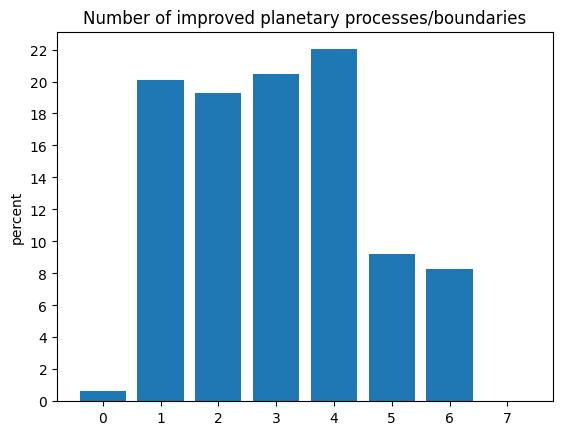

In [34]:
import matplotlib.pyplot as plt
fix, ax = plt.subplots()
ax.set_ylabel("percent")
ax.set_title("Number of improved planetary processes/boundaries")

norm_pb_improvement_cnts_0_1 = {k: 100*v/sum(pb_improvement_cnts.values()) for k, v in pb_improvement_cnts.items()}
plt.bar(pb_improvement_cnts_0_1.keys(), norm_pb_improvement_cnts_0_1.values())
plt.yticks(np.arange(0, max(norm_pb_improvement_cnts_0_1.values()), 2))

## O, 1 and 2 percents

In [26]:
discrete_vals = [0,1,2]

discrete_vals_str = [str(d) for d in discrete_vals]
var_file = root_path / "results" / f"pb_combos_vars_{'_'.join(discrete_vals_str)}.txt"
with open(var_file, "r") as f:
    pbs = json.loads(f.read())

pbs

['Aerosol effect',
 'CO2 effect',
 'Biodiv. incl. climate effect',
 'Biogeochem. effect',
 'Freshwater effect',
 'Ocean acid. effect',
 'Land-use effect']

In [27]:
good_for_all_pbs = []
discrete_vals = [0,1,2]
pb_improvement_cnts = {}    # Out of all the combinations how many improve exactly 1,2,3,4,5,6 boundaries
pb_improvement_cnt_details = {}   # Out of all the combinations that improve exactly 1,2,3,4,5,6 boundaries which one is the most unlikely to improve 
good_for_clim_biod_effects = []
total =len(discrete_vals)**17
import time
st = time.time()
combo_results = pbc.check_combos(discrete_vals, root_path / "results")
pbs = ['Aerosol effect','CO2 effect','Biodiv. incl. climate effect','Biogeochem. effect','Freshwater effect','Ocean acid. effect','Land-use effect']

for c, pb_effects in tqdm(combo_results, total=total):
    sum_pb_effects = sum(pb_effects)
    if sum_pb_effects in pb_improvement_cnts:
        pb_improvement_cnts[sum_pb_effects] += 1 
        for ii, pb in enumerate(pbs):
            pb_improvement_cnt_details[sum_pb_effects][pb] += int(pb_effects[ii])
    else:
        pb_improvement_cnts[sum_pb_effects] = 1
        pb_improvement_cnt_details[sum_pb_effects] = dict(list(zip(pbs, [int(pe) for pe in pb_effects])))

    if pb_effects[1] and pb_effects[2]:
        good_for_clim_biod_effects.append(c)

    if all(pb_effects):
        good_for_all_pbs.append(c)
print(time.time()-st)


  0%|          | 0/129140163 [00:00<?, ?it/s]

loading: pb_0_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:43, 221963.72it/s]


loading: pb_1_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:47, 220319.86it/s]


...

loading: pb_9_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:43, 221821.11it/s]]


loading: pb_10_combos_0_1_2.npy


100%|██████████| 129140163/129140163 [09:55<00:00, 217007.61it/s]

595.0968403816223


In [30]:
pb_improvement_cnts

{0: 791795,
 3: 25990715,
 4: 24934512,
 2: 26428897,
 5: 28432686,
 1: 11883940,
 6: 10677580,
 7: 38}

In [36]:
print(pb_improvement_cnts[6])
pb_improvement_cnt_details[6]

10677580


{'Aerosol effect': 10677580,
 'CO2 effect': 10677580,
 'Biodiv. incl. climate effect': 140,
 'Biogeochem. effect': 10677580,
 'Freshwater effect': 10677501,
 'Ocean acid. effect': 10677580,
 'Land-use effect': 10677519}

In [25]:
tcb=4096 #2**17
pb_improvement_cnts = pb_improvement_cnts_0_1
pb_improvement_cnt_details = pb_improvement_cnt_details_0_1
pb_improvement_cnts = dict(sorted(pb_improvement_cnts.items()))
for ii, (pbsolved, pbcnt) in enumerate(pb_improvement_cnts.items()):
    #print(ii, round(100*pbcnt/tcb, 3), pb_improvement_cnt_details[ii])
    climate_improv = round(100*pb_improvement_cnt_details[ii]['CO2 effect']/pbcnt, 2)
    biodiv_improv = round(100*pb_improvement_cnt_details[ii]['Biodiv. incl. climate effect']/pbcnt, 5)
    print(f"{round(pbcnt*100/tcb,1)}%")
    #print(f"({climate_improv}% / {biodiv_improv}%)")
    #print('---')

0.1%
2.1%
6.5%
6.0%
21.0%
53.3%
11.0%
0.0%


In [15]:


tech_changes = list(prod_change_dict.keys())
df = pd.DataFrame(index=tech_changes, columns=["0%", "1%", "2%"])
good_combos = {k: [] for k in tech_changes}
cnt= 0
for gc in good_for_all_pbs:
    for ii, k in enumerate(tech_changes):
        good_combos[k].append(gc[ii])


for k in tech_changes:
    good_combos[k] = dict(Counter(good_combos[k]))
    df.loc[k, "0%"] = good_combos[k].get(0, 0)
    df.loc[k, "1%"] = good_combos[k].get(1, 0)
    df.loc[k, "2%"] = good_combos[k].get(2, 0)

print('cnt',cnt)
good_combos

df.to_csv(root_path / "results" / 'good_for_all_pbs.csv')

cnt 0


In [23]:
sum_good_for_clim_biod_effects
total=sum(pb_improvement_cnts.values())
pb_improvement_list = sorted(pb_improvement_cnts.items(), key=lambda x: x[0])
pb_improvement_list = [(pbi[0], round(100*pbi[1]/total,6)) for pbi in pb_improvement_list]
for pbi in pb_improvement_list:
    print(pbi[0], str(pbi[1]) + "%")

0 0.613128%
1 9.202358%
2 20.465281%
3 20.125974%
4 19.3081%
5 22.01692%
6 8.26821%
7 2.9e-05%


## -1, O,  and 1 percents

In [20]:
def check(discrete_vals, batches=1):

    good_for_all_pbs = []
    pb_improvement_cnts = {}
    good_for_clim_biod_effects = []
    total =len(discrete_vals)**17
    import time
    st = time.time()
    combo_results = pbc.check_combos(discrete_vals, root_path / "results", batches=batches)
    for c, pb_effects in tqdm(combo_results, total=total):
        sum_pb_effects = sum(pb_effects)
        if sum_pb_effects in pb_improvement_cnts:
            pb_improvement_cnts[sum_pb_effects] += 1 
        else:
            pb_improvement_cnts[sum_pb_effects] = 1

        if pb_effects[1] and pb_effects[2]:
            good_for_clim_biod_effects.append(c)

        if all(pb_effects):
            good_for_all_pbs.append(c)
    print(time.time()-st)
    return good_for_all_pbs, good_for_clim_biod_effects

discrete_vals = [-1,0,1]
good_for_all_pbs__1_0_1, good_for_clim_biod_effects__1_0_1 = check(discrete_vals, batches=10)

  0%|          | 0/129140163 [00:00<?, ?it/s]

loading: pb_0_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:35<05:15, 368684.12it/s]


loading: pb_1_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:34<05:14, 369049.51it/s]


...

loading: pb_9_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:35<05:16, 367562.17it/s]]


loading: pb_10_combos_-1_0_1.npy


100%|██████████| 129140163/129140163 [06:12<00:00, 347002.90it/s]

372.1601872444153


In [27]:
print(len(good_for_all_pbs__1_0_1)/129140163) 
print(len(good_for_clim_biod_effects__1_0_1)/129140163) 

0.03762235455750509
0.32296540465106893


## Check specific combo

In [72]:
def pb_boundary(c, pack=True):
    dfnp = np.array([[0.0010672170921913766, 0.041064083724359594, 0.03606265998995495, -0.09056933011478599, -0.04212802843617142, 0.041064083724359594, -0.009457889673203462, 1.0, 0.0], [0.000280677776028135, 0.008976494788867724, 0.01177139088129886, 0.03526377679207529, 0.01852054800088953, 0.008976494788867724, 0.02102473117337316, 1.0, 0.0], [0.00020340503955239205, 0.006589680358849447, -0.006776759136928323, -0.7402134722784179, 0.022800158842504303, 0.006589680358849447, 0.026026952518861418, 1.0, 0.0], [9.9185328694472e-05, 0.003172095057746263, 0.00415974962560961, 0.012461440095563102, -0.3842849415925758, 0.003172095057746263, 0.0074296757714614955, 1.0, 0.0], [0.003884525919690355, 0.12423294486923242, 0.1629137640898226, 0.48804382346702246, 0.2563207881093982, 0.12423294486923242, 0.290978196967412, 1.0, 0.0], [-0.00024021385317936803, -0.007525790597789012, 0.0038170542693505283, -0.7438123683284646, 0.0015344277486948853, -0.007525790597789012, 0.0020087592144643757, 1.0, -1.0], [0.00014337353262626137, 0.004561989962317463, 0.015669995737233045, -0.47658456002351374, 0.006872888059443555, 0.004561989962317463, 0.007762458447490711, 1.0, 0.0], [0.0003002453601054886, 0.009553480994320743, 0.03281528624420327, 0.48018345607356033, 0.014392843034365638, 0.009553480994320743, 0.01625573485690654, 1.0, 0.0], [-0.0006111707649527577, -0.01246899195121234, -0.002054702421672161, 0.025601994295128286, 0.009820830412398384, -0.01246899195121234, -0.0347027538961542, -1.0, -1.0], [-0.010601937582399506, -0.18222918227136342, 0.006492022805304476, 0.030006844126706043, -0.01827941758527299, -0.18222918227136342, 0.02399593109999751, 0.0, -1.0], [-0.001378795905645309, -0.02429506543859241, 0.001620392870027576, 0.006529822849102153, -0.0011754369121571736, -0.02429506543859241, 0.0016281928468621894, 0.0, -1.0], [-0.011353948105761754, -0.19686385686103025, 0.005973005270065723, 0.05761786114221153, -0.007917923440818157, -0.19686385686103025, -0.011396641580090863, 0.0, -1.0], [0.007955944854472449, 0.2614958180324138, 0.10111898011515574, 0.28702815750204236, 0.16405574909673404, 0.2614958180324138, -0.6538286204894805, 1.0, 0.0], [-4.432538898446151e-05, -0.001712370567540188, 0.007170572698467215, -0.0027423063067561065, -0.0014945870566598976, -0.001712370567540188, 0.0026320395286490873, 0.0, -1.0], [0.00019221806859163147, 0.0017392470741345537, 0.04032729896277232, -0.018034945822891793, -0.00826967604066459, 0.0017392470741345537, 0.014594754586366124, 1.0, -1.0], [1.0008546572808551e-05, -0.0008635002555022078, 0.059912845007070725, -0.0014463897522506383, -0.0005926498932396549, -0.0008635002555022078, 0.013885795678424254, 1.0, 0.0], [0.00013047951009683057, 0.0035842060759157883, 0.15737326705952404, -0.001374217876452746, -0.00039992010625888993, 0.0035842060759157883, -0.01968233909427637, 1.0, -1.0]])
    dc = dfnp * np.array(c).reshape(len(c), 1)
    dc_sum = dc.sum(axis=0)[0:7]<=0
    return dc_sum

In [92]:
tech_params = {
        ("A_LA", "Land use efficiency in agriculture"): 0,
        ("A_EpsA", "Energy efficiency agriculture"): 1,
        ("A_P", "Fertilizer efficiency in agriculture"): 1,
        ("A_W", "Water efficiency in agriculture"): 1,
        ("A_MA", "Other inputs efficiency in agriculture"): 0,
        ("P_EP", "Fossil fuel efficiency in fertilizer prod."): 1,
        ("P_Pho", "Phosphor efficiency in fertilizer prod."): 1,
        ("P_MP", "Other inputs efficiency in fertilizer prod."): 0,
        ("Eps_AB", "Biofuel efficiency in energy service prod."): 1,
        ("Eps_EEps", "Fossil fuel efficiency in energy service prod."): 1,
        ("Eps_R", "Renewable efficiency in energy service prod."): 1,
        ("Y_EpsY", "Energy services efficiency in manufacturing"): 1,
        ("Y_MY", "Other inputs efficiency in manufacturing"): 0,
        ("Fi_EFi", "Fossil fuels efficiency in fisheries"): 1,
        ("Fi_MFi", "Other inputs efficiency in fisheries"): 0,
        ("T_LT", "Land use efficiency in timber prod."): 1,
        ("T_MT", "Other inputs efficiency in timber prod."): 0,
    }
#tech_params = {k: int(v==0) for k,v in tech_params.items()}
results=pb_boundary(list(tech_params.values()), pack=False)
pbs = {'Aerosol effect': None,
 'CO2 effect': None,
 'Biodiv. incl. climate effect': None,
 'Biogeochem. effect': None,
 'Freshwater effect': None,
 'Ocean acid. effect': None,
 'Land-use effect': None
 }
{pb: results[ii] for ii, (pb, _) in enumerate(pbs.items())}

{'Aerosol effect': True,
 'CO2 effect': True,
 'Biodiv. incl. climate effect': False,
 'Biogeochem. effect': True,
 'Freshwater effect': True,
 'Ocean acid. effect': True,
 'Land-use effect': False}

# Latte

In [15]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import PBcombos as pbc
importlib.reload(pbc)

tech_params = {
    ("A_LA", "Land use efficiency in agriculture"): 1,
    ("A_EpsA", "Energy efficiency agriculture"): 1,
    ("A_P", "Fertilizer efficiency in agriculture"): 1,
    ("A_W", "Water efficiency in agriculture"): 1,
    ("A_MA", "Other inputs efficiency in agriculture"): 0,
    ("P_EP", "Fossil fuel efficiency in fertilizer prod."): 1,
    ("P_Pho", "Phosphor efficiency in fertilizer prod."): 1,
    ("P_MP", "Other inputs efficiency in fertilizer prod."): 0,
    ("Eps_AB", "Biofuel efficiency in energy service prod."): 1,
    ("Eps_EEps", "Fossil fuel efficiency in energy service prod."): 1,
    ("Eps_R", "Renewable efficiency in energy service prod."): 1,
    ("Y_EpsY", "Energy services efficiency in manufacturing"): 1,
    ("Y_MY", "Other inputs efficiency in manufacturing"): 0,
    ("Fi_EFi", "Fossil fuels efficiency in fisheries"): 1,
    ("Fi_MFi", "Other inputs efficiency in fisheries"): 0,
    ("T_LT", "Land use efficiency in timber prod."): 1,
    ("T_MT", "Other inputs efficiency in timber prod."): 0,
}
boundaries = {'Aerosol effect': 1,
 'CO2 effect': 1,
 'Biodiv. incl. climate effect': 1,
 'Biogeochem. effect': 1,
 'Freshwater effect': 1,
 'Ocean acid. effect': 1,
 'Land-use effect': 1
}
result, tech_param_range = pbc.gen_latte(tech_params, boundaries, constraints=[0,1])

['Ray Support Algorithm.', 'The codimension is 22', '', '  Left =  10,  Col =  21,  Size =       13  Time:  0.00', '  Left =  10,  Col =  21,  Size =       13,   Index = 0/4', '  Left =  10,  Col =  21,  Size =       40,  Time:  0.00                ', '', '  Left =   9,  Col =  16,  Size =       40  Time:  0.00', '  Left =   9,  Col =  16,  Size =       20,   Index = 0/12', '  Left =   9,  Col =  16,  Size =      100,  Time:  0.00                ', '', '  Left =   8,  Col =  20,  Size =      100  Time:  0.00', '  Left =   8,  Col =  20,  Size =       20,   Index = 0/11', '  Left =   8,  Col =  20,  Size =      105,  Time:  0.00                ', '', '  Left =   7,  Col =  14,  Size =      105  Time:  0.00', '  Left =   7,  Col =  14,  Size =       37,   Index = 0/31', '  Left =   7,  Col =  14,  Size =      154,  Time:  0.00                ', '', '  Left =   6,  Col =  18,  Size =      154  Time:  0.00', '  Left =   6,  Col =  18,  Size =       70,   Index = 0/63', '  Left =   6,  Col 

In [21]:
float(result)


2.5814775329316394e-09

In [1]:
tech_param_range = {('A_LA', 'Land use efficiency in agriculture'): [0.2347951156432666, 0],
 ('A_EpsA', 'Energy efficiency agriculture'): [0.6319727089993222, 0],
 ('A_P', 'Fertilizer efficiency in agriculture'): [1, 0],
 ('A_W', 'Water efficiency in agriculture'): [1, 0],
 ('A_MA', 'Other inputs efficiency in agriculture'): [0.04566340864646694, 0],
 ('P_EP', 'Fossil fuel efficiency in fertilizer prod.'): [1, 0],
 ('P_Pho', 'Phosphor efficiency in fertilizer prod.'): [0.5384997157536912, 0],
 ('P_MP', 'Other inputs efficiency in fertilizer prod.'): [0.25714504476637556,
  0],
 ('Eps_AB', 'Biofuel efficiency in energy service prod.'): [1, 0],
 ('Eps_EEps',
  'Fossil fuel efficiency in energy service prod.'): [0.9718551674161944, 0],
 ('Eps_R', 'Renewable efficiency in energy service prod.'): [1, 0],
 ('Y_EpsY', 'Energy services efficiency in manufacturing'): [1, 0],
 ('Y_MY', 'Other inputs efficiency in manufacturing'): [0.07806629925333382,
  0],
 ('Fi_EFi', 'Fossil fuels efficiency in fisheries'): [1, 0],
 ('Fi_MFi', 'Other inputs efficiency in fisheries'): [0.21070621307424173, 0],
 ('T_LT', 'Land use efficiency in timber prod.'): [0.14152655783303345, 0],
 ('T_MT', 'Other inputs efficiency in timber prod.'): [0.053875630750604545,
  0]}

In [15]:
df = pd.DataFrame.from_dict({k[1]: v[0]*1 for k, v in tech_param_range.items()}, orient='index')
df.columns = ["space"]
df

,space
Land use efficiency in agriculture,0.2348
Energy efficiency agriculture,0.6320
Fertilizer efficiency in agriculture,1.0000
Water efficiency in agriculture,1.0000
Other inputs efficiency in agriculture,0.0457
Fossil fuel efficiency in fertilizer prod.,1.0000
Phosphor efficiency in fertilizer prod.,0.5385
Other inputs efficiency in fertilizer prod.,0.2571
Biofuel efficiency in energy service prod.,1.0000
Fossil fuel efficiency in energy service prod.,0.9719


-0.2 0 1.0
0.8 0 1.0
1.8 0 0.5384997157536912
2.8 0 0.14152655783303345
3.8 0 0.2347951156432666
4.8 0 1.0
5.8 0 1.0
6.8 0 0.8627951575808473
7.8 0 1.0
8.8 0 1.0
9.8 0 0.6066568025098343
10.8 0 1.0
0.009366196207174608


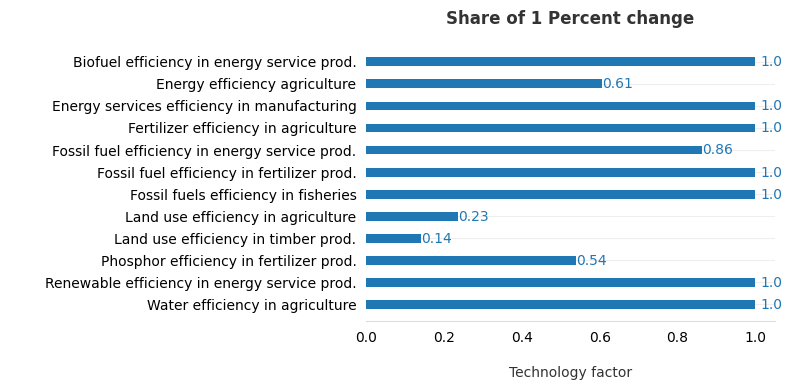

In [20]:
# Use Matplotlib's font manager to rebuild the font library.
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager
plt.rcdefaults()
# Use the newly integrated Roboto font family for all text.
plt.rc('font', family='sans-serif')
plt.rcParams['figure.figsize'] = (8, 4)
fig, ax = plt.subplots()

df = pd.DataFrame.from_dict({k[1]: v[0] for k, v in tech_param_range.items() if v}, orient='index').sort_index(ascending=False)
df.columns = ["space"]

# Save the chart so we can loop through the bars below.
bars = ax.barh(
    df.index,
    df['space'], 
    height = 0.4,
    align = 'center',
)

# Axis formatting.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#DDDDDD')
ax.tick_params(bottom=False, left=False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#EEEEEE')
ax.xaxis.grid(False)

# Add text annotations to the top of the bars.
bar_color = bars[0].get_facecolor()
vol= 1
for bar in bars:
  vol = vol* bar.get_width()
  print(bar.get_y(),bar.get_x(), bar.get_width())
  ax.text(
      bar.get_width() + 0.04,
      bar.get_y(),
      round(bar.get_width(), 2),
      horizontalalignment='center',
      color=bar_color,
      weight='normal'
  )

# Add labels and a title.
ax.set_xlabel('Technology factor', labelpad=15, color='#333333', )
ax.set_ylabel(' ', labelpad=15, color='#333333')
ax.set_title('Share of 1 Percent change', pad=15, color='#333333',
             weight='bold')
print(vol)
fig.tight_layout()

In [9]:
(7.5e-17)/1.1436473857795216e-07

6.557965412466644e-10

/tmp/ipykernel_2345704/4171593686.py:42: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



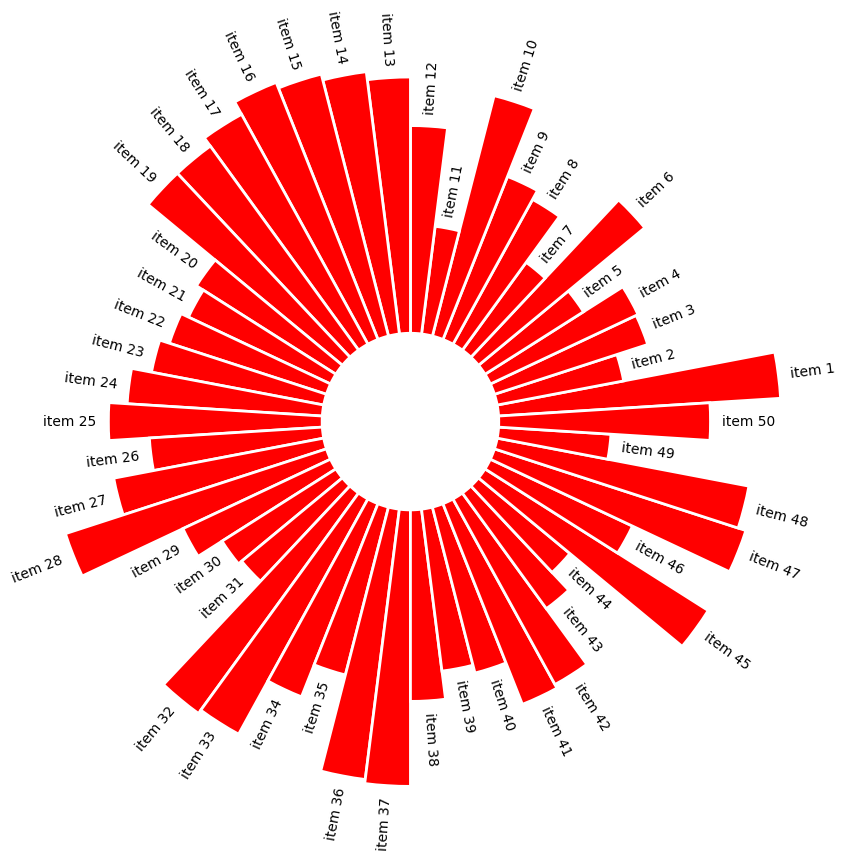

In [35]:
# import pandas for data wrangling
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Build a dataset
df = pd.DataFrame(
        {
            'Name': ['item ' + str(k[0]) for k in tech_param_range.keys() ],
            'Value': np.random.randint(low=10, high=100, size=50)
        })


# initialize the figure
plt.figure(figsize=(20,10))
ax = plt.subplot(111, polar=True)
plt.axis('off')

# Constants = parameters controling the plot layout:
upperLimit = 100
lowerLimit = 30
labelPadding = 4

# Compute max and min in the dataset
max = df['Value'].max()

# Let's compute heights: they are a conversion of each item value in those new coordinates
# In our example, 0 in the dataset will be converted to the lowerLimit (10)
# The maximum will be converted to the upperLimit (100)
slope = (max - lowerLimit) / max
heights = slope * df.Value + lowerLimit

# Compute the width of each bar. In total we have 2*Pi = 360°
width = 2*np.pi / len(df.index)

# Compute the angle each bar is centered on:
indexes = list(range(1, len(df.index)+1))
angles = [element * width for element in indexes]
angles

# Draw bars
bars = ax.bar(
    x=angles, 
    height=heights, 
    width=width, 
    bottom=lowerLimit,
    linewidth=2, 
    edgecolor="white",
    color="red",
)
      

# Add labels
for bar, angle, height, label in zip(bars,angles, heights, df["Name"]):

    # Labels are rotated. Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle)

    bar.color=cmap(lowerLimit + bar.get_height() + labelPadding),

    # Flip some labels upside down
    alignment = ""
    if angle >= np.pi/2 and angle < 3*np.pi/2:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"

    ax.imshow
    # Finally add the labels
    ax.text(
        x=angle, 
        y=lowerLimit + bar.get_height() + labelPadding, 
        s=label, 
        ha=alignment, 
        va='center', 
        rotation=rotation, 
        rotation_mode="anchor") 

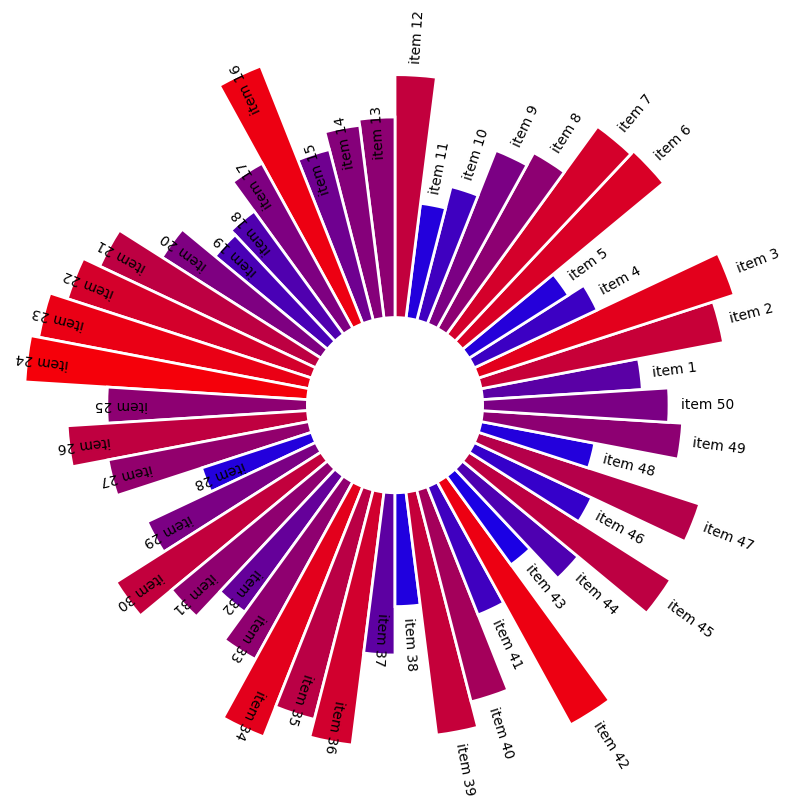

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Build a dataset
df = pd.DataFrame(
        {
            'Name': ['item ' + str(i) for i in list(range(1, 51))],
            'Value': np.random.randint(low=10, high=100, size=50)
        })

# Initialize the figure
plt.figure(figsize=(20, 10))
ax = plt.subplot(111, polar=True)
plt.axis('off')

# Constants = parameters controlling the plot layout
upperLimit = 100
lowerLimit = 30
labelPadding = 4

# Compute max and min in the dataset
max_val = df['Value'].max()

# Let's compute heights: they are a conversion of each item value in those new coordinates
# In our example, 0 in the dataset will be converted to the lowerLimit (10)
# The maximum will be converted to the upperLimit (100)
slope = (max_val - lowerLimit) / max_val
heights = slope * df.Value + lowerLimit

# Compute the width of each bar. In total we have 2*Pi = 360°
width = 2 * np.pi / len(df.index)

# Compute the angle each bar is centered on
indexes = list(range(1, len(df.index) + 1))
angles = [element * width for element in indexes]

# Create a blue to red colormap
colors = [(0, 'blue'), (1, 'red')]
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Draw bars with gradient fill
for angle, height, label in zip(angles, heights, df["Name"]):
    bar = ax.bar(x=angle, height=height, width=width, bottom=lowerLimit, linewidth=2, edgecolor="white")
    for b in bar:
        b.set_facecolor(cmap((b.get_height() - lowerLimit) / (upperLimit - lowerLimit)))

# Add labels
for angle, height, label in zip(angles, heights, df["Name"]):
    # Labels are rotated. Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle)

    # Flip some labels upside down
    alignment = "right" if angle >= np.pi / 2 and angle < 3 * np.pi / 2 else "left"

    # Finally add the labels
    ax.text(
        x=angle,
        y=lowerLimit + height + labelPadding,
        s=label,
        ha=alignment,
        va='center',
        rotation=rotation,
        rotation_mode="anchor")

plt.show()


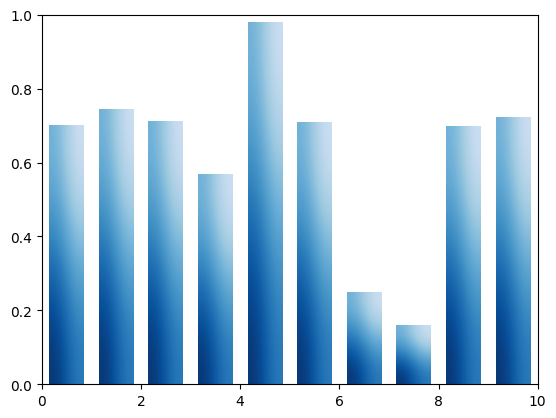

In [44]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(19680801)


def gradient_image(ax, extent, direction=0.3, cmap_range=(0, 1), **kwargs):
    """
    Draw a gradient image based on a colormap.

    Parameters
    ----------
    ax : Axes
        The axes to draw on.
    extent
        The extent of the image as (xmin, xmax, ymin, ymax).
        By default, this is in Axes coordinates but may be
        changed using the *transform* kwarg.
    direction : float
        The direction of the gradient. This is a number in
        range 0 (=vertical) to 1 (=horizontal).
    cmap_range : float, float
        The fraction (cmin, cmax) of the colormap that should be
        used for the gradient, where the complete colormap is (0, 1).
    **kwargs
        Other parameters are passed on to `.Axes.imshow()`.
        In particular useful is *cmap*.
    """
    phi = direction * np.pi / 2
    v = np.array([np.cos(phi), np.sin(phi)])
    X = np.array([[v @ [1, 0], v @ [1, 1]],
                  [v @ [0, 0], v @ [0, 1]]])
    a, b = cmap_range
    X = a + (b - a) / X.max() * X
    im = ax.imshow(X, extent=extent, interpolation='bicubic',
                   vmin=0, vmax=1, **kwargs)
    return im


def gradient_bar(ax, x, y, width=0.5, bottom=0):
    for left, top in zip(x, y):
        right = left + width
        gradient_image(ax, extent=(left, right, bottom, top),
                       cmap=plt.cm.Blues_r, cmap_range=(0, 0.8))


xmin, xmax = xlim = 0, 10
ymin, ymax = ylim = 0, 1

fig, ax = plt.subplots()
ax.set(xlim=xlim, ylim=ylim, autoscale_on=False)

# background image


N = 10
x = np.arange(N) + 0.15
y = np.random.rand(N)
gradient_bar(ax, x, y, width=0.7)
ax.set_aspect('auto')
plt.show()


23863.178579442014 1220.2305005635694 81395.63879181579 7991.189490001913
891.7146679554412 474.0866317162112 905.0211482438431 483.33625449719807
-34121.81224445963 -7375.257515388886 -29930.497083958602 -4705.606850588187
2840.091762235693 949.7063239500361 2987.1834475443557 1072.2414190661016
-3821.073013950634 -1346.949903689277 -3244.246405258901 -954.7518440383417
2887.592030985844 1356.592347751091 3253.1310982761183 1542.1972616020123
-2682.289559152447 -1731.2113469590681 -2081.8019008232886 -1365.456159483899
2822.826254827054 1994.8207387884415 3281.056040894401 2165.8841811763627
-3143.131984225338 -3616.5446825909676 -2251.89264136975 -3271.4445344988594
3061.5553673861577 4277.471653382085 4121.466056471318 4542.319419057506
-1995.9490461862251 -5630.715042738837 -532.7656487339184 -5349.955599232613
1025.000000000001 8196.220088383445 3014.0493612263654 8378.849831770254
1024.999999999998 -16720.129779647403 5368.276904343062 -16445.357898206898
-10780.372549257076 2322

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

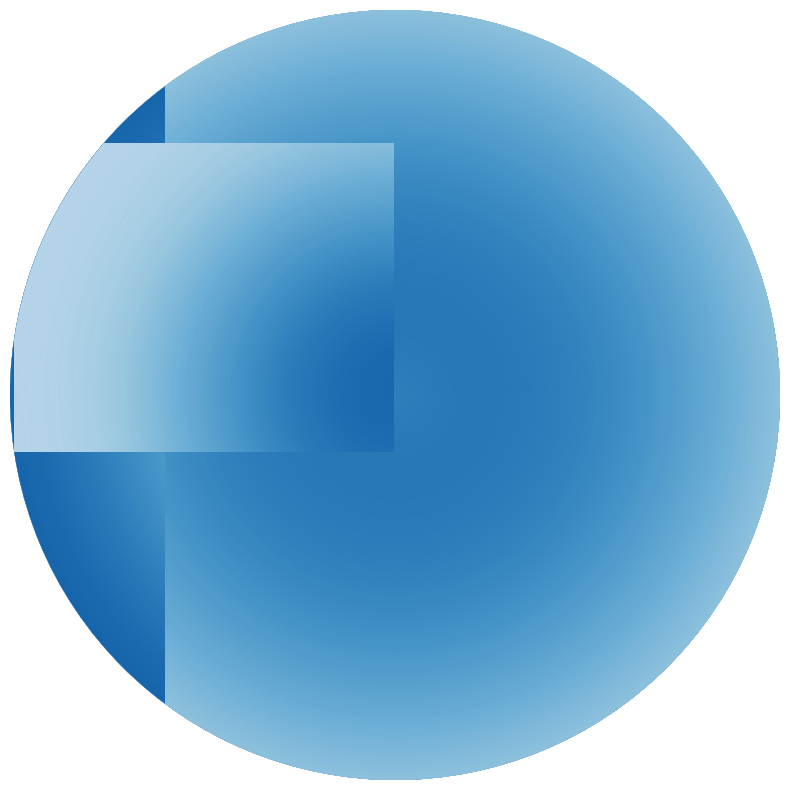

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Build a dataset
df = pd.DataFrame(
        {
            'Name': ['item ' + str(i) for i in list(range(1, 51)) ],
            'Value': np.random.randint(low=10, high=100, size=50)
        })


# initialize the figure
plt.figure(figsize=(20,10))
ax = plt.subplot(111, polar=True)
plt.axis('off')

# Constants = parameters controling the plot layout:
upperLimit = 100
lowerLimit = 30
labelPadding = 4

# Compute max and min in the dataset
max = df['Value'].max()

# Let's compute heights: they are a conversion of each item value in those new coordinates
# In our example, 0 in the dataset will be converted to the lowerLimit (10)
# The maximum will be converted to the upperLimit (100)
slope = (max - lowerLimit) / max
heights = slope * df.Value + lowerLimit

# Compute the width of each bar. In total we have 2*Pi = 360°
width = 2*np.pi / len(df.index)

# Compute the angle each bar is centered on:
indexes = list(range(1, len(df.index)+1))
angles = [element * width for element in indexes]
angles

# Draw bars
bars = ax.bar(
    x=angles, 
    height=heights, 
    width=width, 
    bottom=lowerLimit,
    linewidth=2, 
    edgecolor="white",
    color="red",
)
      

# Add labels
for bar, angle, height, label in zip(bars,angles, heights, df["Name"]):

    # Labels are rotated. Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle)

    bar.color=cmap(lowerLimit + bar.get_height() + labelPadding),

    # Flip some labels upside down
    alignment = ""
    if angle >= np.pi/2 and angle < 3*np.pi/2:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"

    bbox = bar.get_window_extent()
    print(bbox.x0, bbox.y0, bbox.x1, bbox.y1)
    gradient_image(ax, extent=(bbox.x0, bbox.x1, bbox.y0, bbox.y1),
                       cmap=plt.cm.Blues_r, cmap_range=(0, 0.8))
    
    ax.imshow
    # Finally add the labels
    ax.text(
        x=angle, 
        y=lowerLimit + bar.get_height() + labelPadding, 
        s=label, 
        ha=alignment, 
        va='center', 
        rotation=rotation, 
        rotation_mode="anchor") 

In [71]:
from collections import Counter
df.loc[df.direction=="E", ["frequency","strength"]].sort_values("strength")

,frequency,strength
4,0.4,0-1
20,1.6,1-2
36,1.0,2-3
52,0.8,3-4
68,0.4,4-4
84,0.1,4-5
100,0.1,5-6
116,0.1,6+


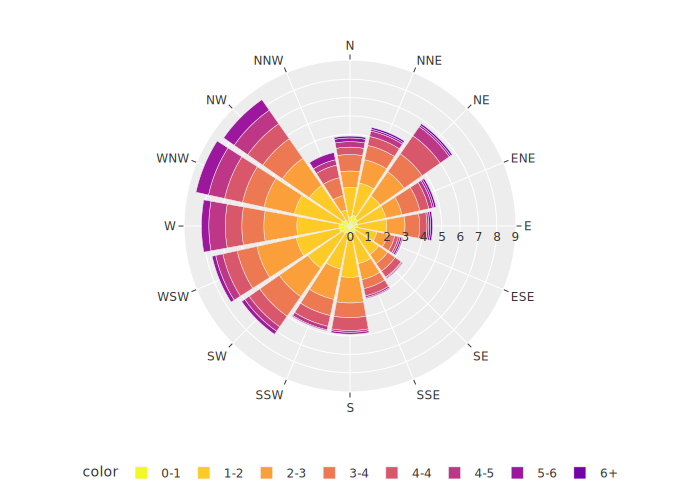

In [62]:
import plotly.io as pio
pio.renderers.default = 'svg'
#pio.renderers.default = 'browser'

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = px.data.wind()
plotly_colorscales = px.colors.named_colorscales()
size=118
fig = px.bar_polar(df, r=df["frequency"][0:size], theta=df["direction"][0:size],
                    color=df["strength"][0:size], template="ggplot2",
                    color_discrete_sequence= px.colors.sequential.Plasma_r
                    #color_continuous_scale='blugrn'
                    )



fig.update_layout(legend=dict(
    orientation="h",
    yanchor="top",
    y=-0.2,
    xanchor="center",
    x=0.5),
    polar=dict(radialaxis=dict(showticklabels=True, ticks='', dtick=1, linewidth=0), 
    )
)

fig.update_polars(angularaxis_dtick=1, 
                  angularaxis_exponentformat="power")

fig.show()

In [54]:
px.colors.sequential.Plasma_r

['#f0f921',
 '#fdca26',
 '#fb9f3a',
 '#ed7953',
 '#d8576b',
 '#bd3786',
 '#9c179e',
 '#7201a8',
 '#46039f',
 '#0d0887']

In [41]:
help(px.bar_polar)

Help on function bar_polar in module plotly.express._chart_types:

bar_polar(data_frame=None, r=None, theta=None, color=None, pattern_shape=None, hover_name=None, hover_data=None, custom_data=None, base=None, animation_frame=None, animation_group=None, category_orders=None, labels=None, color_discrete_sequence=None, color_discrete_map=None, color_continuous_scale=None, pattern_shape_sequence=None, pattern_shape_map=None, range_color=None, color_continuous_midpoint=None, barnorm=None, barmode='relative', direction='clockwise', start_angle=90, range_r=None, range_theta=None, log_r=False, title=None, template=None, width=None, height=None) -> plotly.graph_objs._figure.Figure
        In a polar bar plot, each row of `data_frame` is represented as a wedge
        mark in polar coordinates.

    Parameters
    ----------
    data_frame: DataFrame or array-like or dict
        This argument needs to be passed for column names (and not keyword
        names) to be used. Array-like and dict are